In [1]:
# === Core Python Utilities ===
import os
import re
import math
import random
import warnings
from datetime import datetime
from itertools import combinations
from collections import Counter
from typing import List, Tuple, Dict, Optional

# === Scientific Computing ===
import numpy as np
import pandas as pd
import scipy
from scipy.stats import skew

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
import mplcursors
from matplotlib.colors import LinearSegmentedColormap

# === Progress & Optimization ===
from tqdm.notebook import tqdm
tqdm.pandas()

# === Machine Learning Models ===
from sklearn.ensemble import HistGradientBoostingClassifier

# from catboost import CatBoostClassifier, CatBoostRegressor, Pool, cv
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [2]:
from training_module import (
    evaluate_model,                     # Hàm thực hiện đánh giá mô hình trên tập dev và test
    optimize_threshold_by_f1           # Hàm thực hiện tối ưu hoá ngưỡng phân loại
)

In [3]:
# Một số setting cơ bản
import warnings
import pandas as pd
warnings.filterwarnings ('ignore')
pd.set_option ('display.width', None)
pd.set_option ('display.max_rows', 100)
pd.set_option ('display.max_columns', 50)

In [4]:
file_path = '/Users/kittnguyen/Documents/us-flight-project/data/silver_data/'
X_train = np.load(f"{file_path}train/X_train.npy", allow_pickle=True)
y_train = np.load(f"{file_path}train/y_train.npy", allow_pickle=True)
X_dev = np.load(f"{file_path}dev/X_dev.npy", allow_pickle=True)
y_dev = np.load(f"{file_path}dev/y_dev.npy", allow_pickle=True)
X_test = np.load(f"{file_path}test/X_test.npy", allow_pickle=True)
y_test = np.load(f"{file_path}test/y_test.npy", allow_pickle=True)

# Hist Gradient Boosting

## a. Training

In [5]:
# --- HistGradientBoosting Classifier ---
hgb_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_depth=10,
    # class_weight='balanced',
    class_weight={0: 1, 1: 2},
    random_state=42
)

# --- Training ---
hgb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,10
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


## b. Predicting & Evaluating

### Dev

Evaluation on  set:
Accuracy : 0.6393
Precision: 0.5175
Recall   : 0.7173
F1-score : 0.6012
ROC AUC  : 0.7180


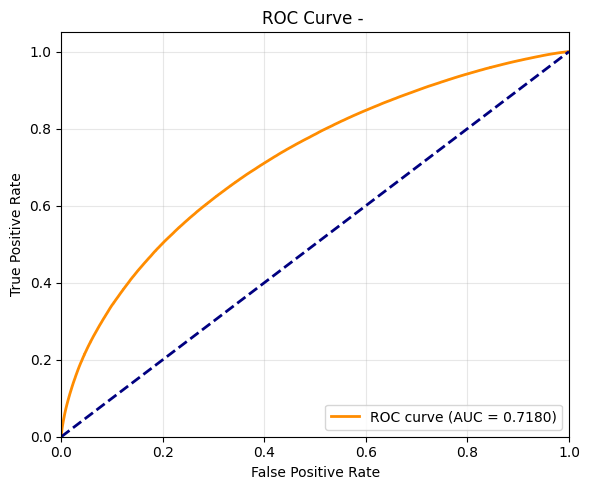

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.59      0.67    837529
           1       0.52      0.72      0.60    511152

    accuracy                           0.64   1348681
   macro avg       0.65      0.65      0.64   1348681
weighted avg       0.68      0.64      0.64   1348681



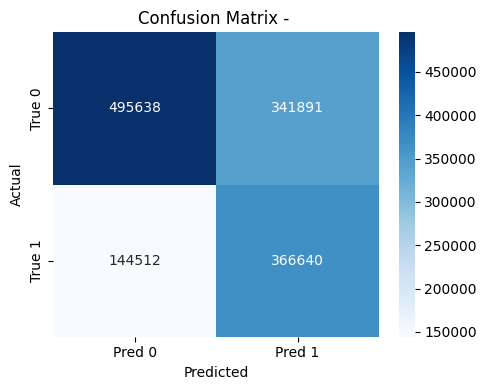

Best threshold: 0.50 with F1-score: 1.0000


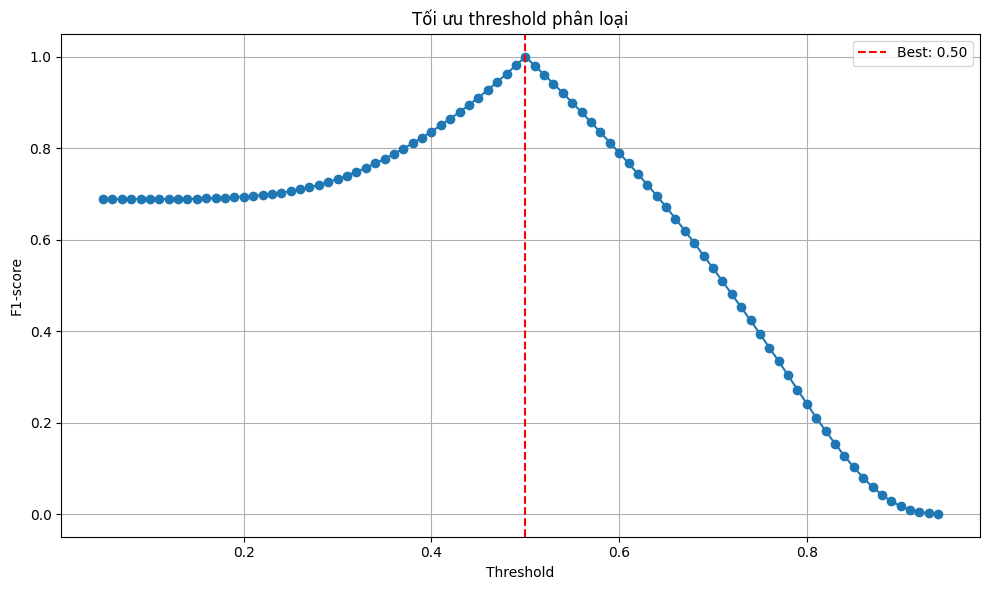

(np.float64(0.5000000000000001), 1.0)

In [6]:
# --- Predicting ---
y_pred_dev = hgb_model.predict(X_dev)
y_proba_dev = hgb_model.predict_proba(X_dev)[:, 1] # Probability

# --- Evaluating ---
evaluate_model (y_dev, y_pred_dev, y_proba_dev)

# --- Optimizing ---
optimize_threshold_by_f1 (hgb_model, X_dev, y_pred_dev)

### Test

Evaluation on  set:
Accuracy : 0.6675
Precision: 0.554
Recall   : 0.6301
F1-score : 0.5896
ROC AUC  : 0.7188


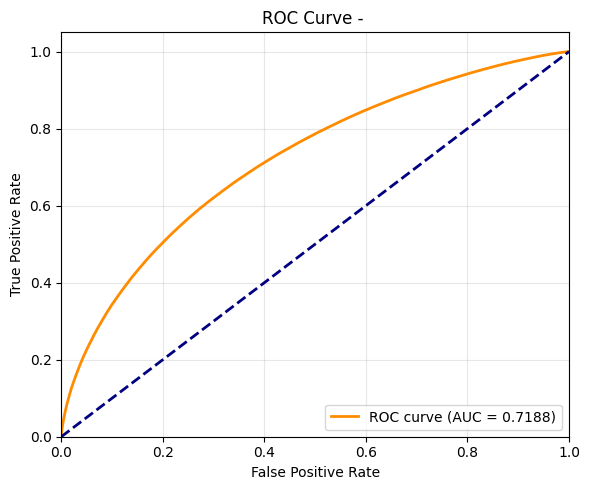

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.69      0.72    837529
           1       0.55      0.63      0.59    511152

    accuracy                           0.67   1348681
   macro avg       0.65      0.66      0.66   1348681
weighted avg       0.68      0.67      0.67   1348681



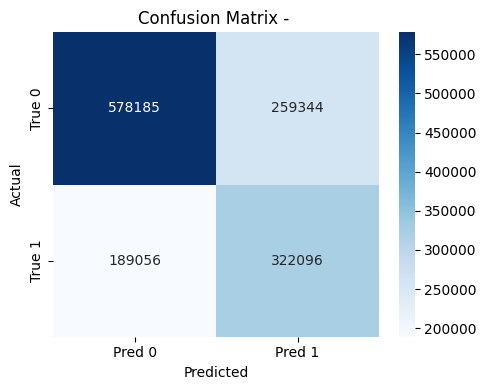

Best threshold: 0.50 with F1-score: 1.0000


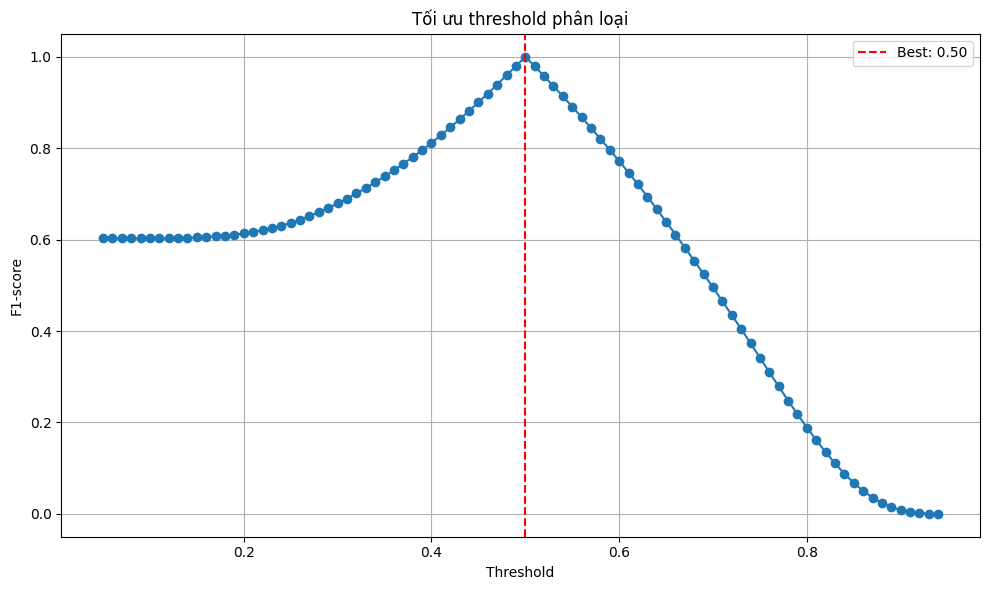

(np.float64(0.5000000000000001), 1.0)

In [7]:
# --- Predicting ---
y_pred_test = hgb_model.predict(X_test)
y_proba_test = hgb_model.predict_proba(X_test)[:, 1] # Probability

# --- Evaluating ---
evaluate_model (y_test, y_pred_test, y_proba_test)

# --- Optimizing ---
optimize_threshold_by_f1 (hgb_model, X_test, y_pred_test)